# Customer Intelligence System using Machine Learning

## Objective
  - To develope an end-to-end Customer Intelligence System using classification, ensemble learning (Random Forest, XGBoost), and clustering (K-Means, DBSCAN), achieving optimized predictive performance and actionable customer segmentation insights.

In [34]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, DBSCAN

from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [35]:
df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Exploratory Data Analysis (EDA)

It is performed to understand the dataset, identify missing values, check data types, and summarize the statistical properties 

Dataset Shape: (167, 10)

Columns:
Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB

Statistical Summary:
Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_e

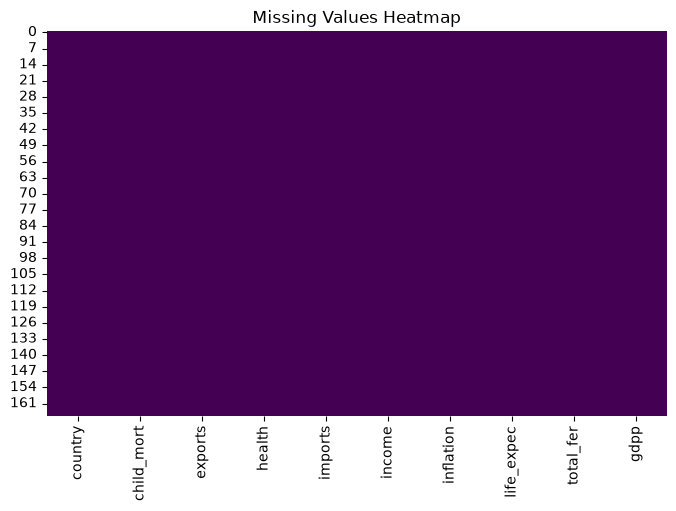

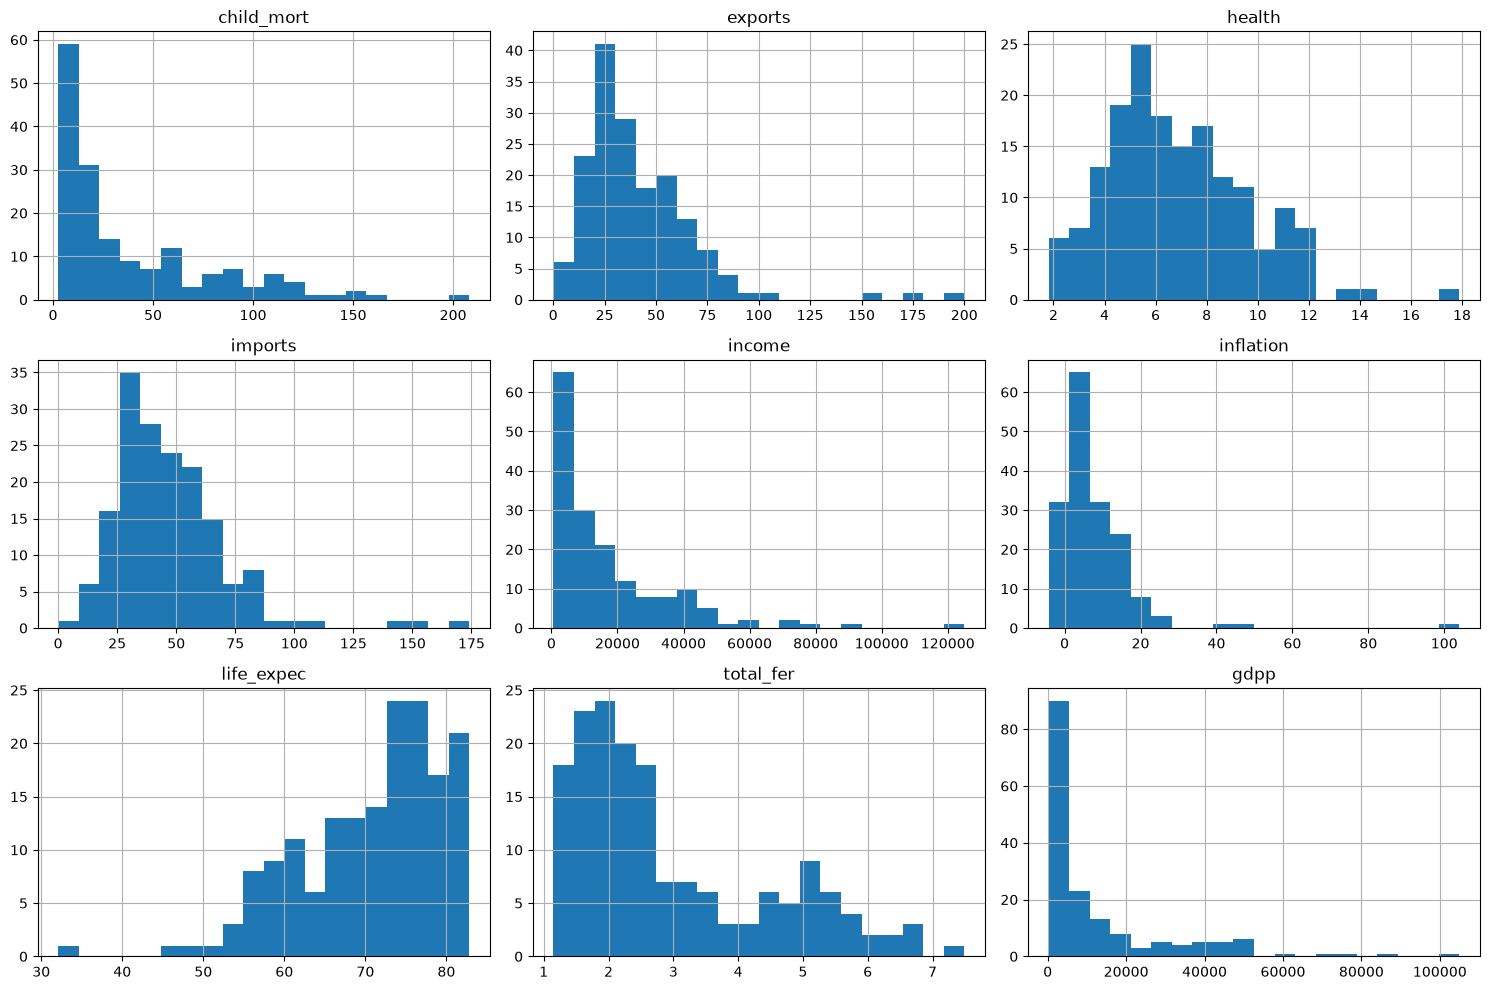

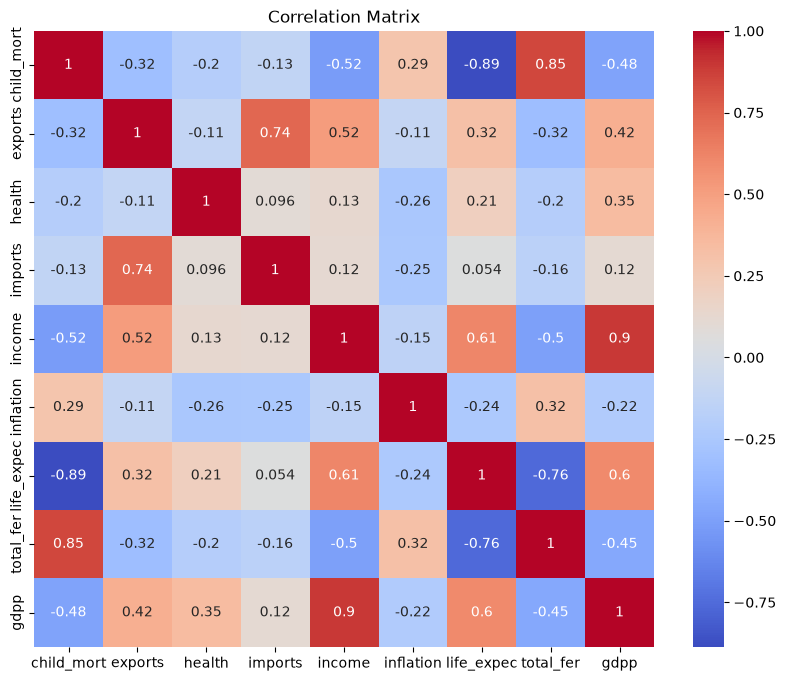

In [36]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
df.describe()

print("Missing Values:")
print(df.isnull().sum())

print("Duplicate Rows:", df.duplicated().sum())

plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")

df.hist(figsize=(15,10), bins=20)
plt.tight_layout()

plt.figure(figsize=(10,8))
sns.heatmap(df.drop('country', axis=1).corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

## Feature Scaling

In [37]:

df_processed = df.copy()

X = df_processed.drop(columns=['country'])

X.head()
scaler = StandardScaler()

# Scale the features
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## Principal Component Analysis (PCA)
It is used to reduce the dimensionality of the dataset while preserving most of the information. It helps visualize high-dimensional data in two dimensions.

In [38]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Convert to DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

pca_df.head()

,PC1,PC2
0,-2.913025,0.095621
1,0.429911,-0.588156
2,-0.285225,-0.455174
3,-2.932423,1.695555
4,1.033576,0.136659


## Finding the Optimal Number of Clusters (Elbow Method)
 The Elbow Method helps identify the value of K where adding more clusters does not significantly reduce the clustering error.

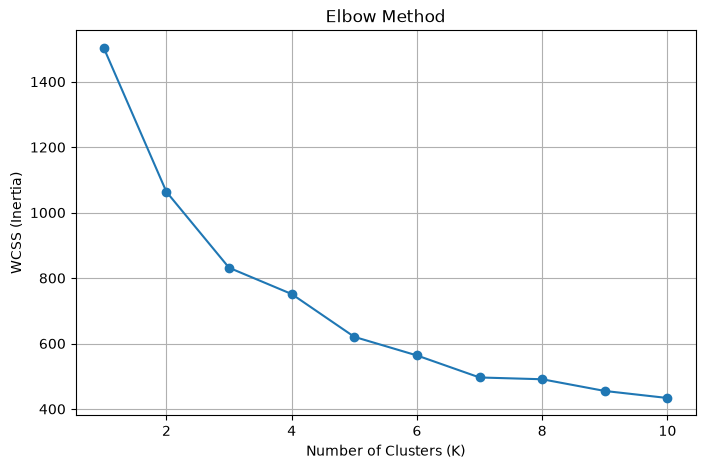

In [39]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

## K-Means Clustering

In [40]:
# Train K-Means
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataset
df['Cluster'] = clusters

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


### Visualization

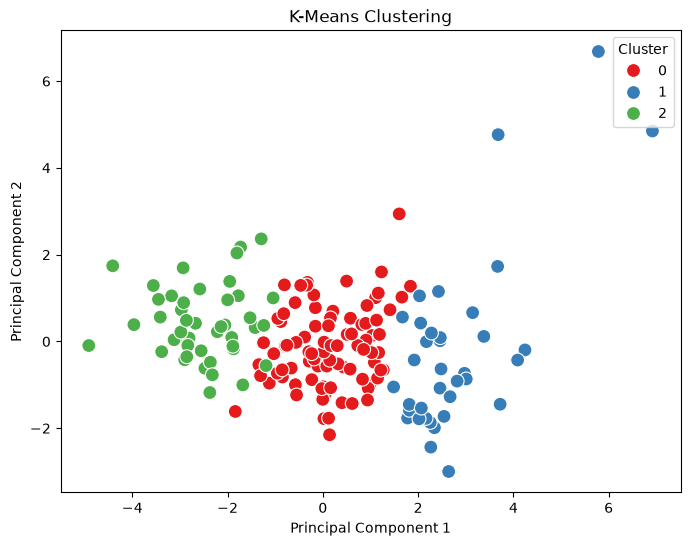

In [41]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)

plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

## DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups data points based on their density. Unlike K-Means, it does not require specifying the number of clusters in advance and can identify outliers as noise.

In [42]:
dbscan = DBSCAN(eps=0.8, min_samples=5)

dbscan_clusters = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_clusters

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,DBSCAN_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2,-1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0,-1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0,0


### Visualization

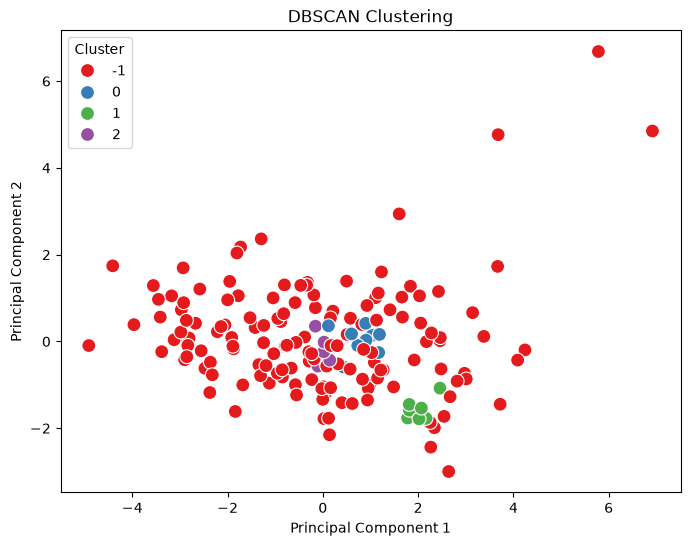

In [43]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=df['DBSCAN_Cluster'],
    palette='Set1',
    s=100
)

plt.title("DBSCAN Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

## Clustering Evaluation

The quality of clustering is evaluated using the Silhouette Score. A higher Silhouette Score indicates better-defined and well-separated clusters.

In [44]:
kmeans_score = silhouette_score(X_scaled, clusters)

print("K-Means Silhouette Score :", round(kmeans_score,3))

K-Means Silhouette Score : 0.286


### DBSCAN Evaluation

In [45]:
# Remove noise points
mask = dbscan_clusters != -1

if len(set(dbscan_clusters[mask])) > 1:
    dbscan_score = silhouette_score(
        X_scaled[mask],
        dbscan_clusters[mask]
    )
    print("DBSCAN Silhouette Score :", round(dbscan_score,3))
else:
    print("DBSCAN produced only one cluster. Silhouette Score cannot be calculated.")

DBSCAN Silhouette Score : 0.441


In [46]:
print(df["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
-1    146
 0      9
 1      7
 2      5
Name: count, dtype: int64


# Classification using Machine Learning

In this section, the clusters generated by the K-Means algorithm are used as target labels. Classification models are trained to predict the cluster of a country based on its socio-economic features.

In [47]:
# Features
X = X_scaled

# Target
y = df["Cluster"]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (133, 9)
Testing Data : (34, 9)


## Random Forest Classification

In [50]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy : 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



## XGBoost Classification

In [51]:
# Initialize Model
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42
)

# Train Model
xgb.fit(X_train, y_train)

# Predictions
xgb_pred = xgb.predict(X_test)

# Evaluation
print("XGBoost Accuracy :", accuracy_score(y_test, xgb_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy : 0.9705882352941176

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



## AdaBoost Classification

In [52]:
from sklearn.ensemble import AdaBoostClassifier
# Initialize Model
ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
ada.fit(X_train, y_train)

# Predictions
ada_pred = ada.predict(X_test)

# Evaluation
print("AdaBoost Accuracy :", accuracy_score(y_test, ada_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, ada_pred))

AdaBoost Accuracy : 0.9705882352941176

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



## Model Comparison

In [53]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "AdaBoost", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, ada_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, rf_pred, average='weighted'),
        f1_score(y_test, ada_pred, average='weighted'),
        f1_score(y_test, xgb_pred, average='weighted')
    ]
})

comparison

,Model,Accuracy,F1 Score
0,Random Forest,0.970588,0.970942
1,AdaBoost,0.970588,0.970942
2,XGBoost,0.970588,0.970942


## Feature Importance

 Identifies the most influential features used by the model while making predictions. It helps understand which socio-economic indicators contribute the most to customer segmentation.

      Feature  Importance
0  child_mort    0.296120
8        gdpp    0.227301
4      income    0.164629
6  life_expec    0.164469
7   total_fer    0.097647
2      health    0.017380
1     exports    0.011820
5   inflation    0.011761
3     imports    0.008873


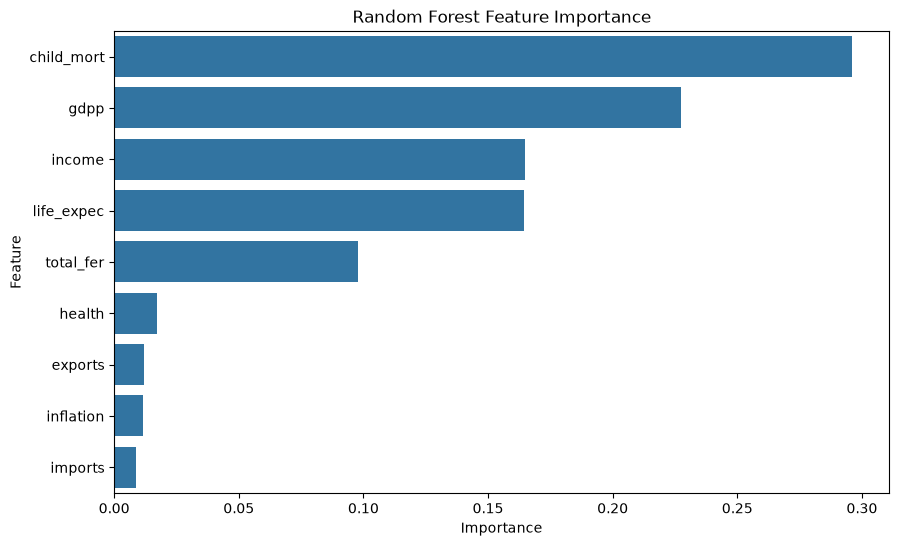

In [54]:
# Feature Importance - Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.show()

## Conclusion

An end-to-end Customer Intelligence System was successfully developed using clustering and classification techniques.

- K-Means clustering effectively segmented countries into meaningful groups.
- DBSCAN identified potential outliers. 
- Ensemble learning models such as Random Forest, AdaBoost, and XGBoost demonstrated excellent predictive performance with approximately 97% accuracy.

The analysis provides valuable customer segmentation insights and highlights the most significant socio-economic features influencing the classification process.